In [75]:
# Auto reload for Jupyter notebooks - only reloads modules that have been edited since the last update
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore') # Hide all warning for cleaner output

import logging
logging.getLogger("transformers").setLevel(logging.ERROR) # Only show errrors from transformers library

# Import the main module for ASD detection
import advance_asd_detection as asd

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Processing all modalities...

----- FINAL SYSTEM PREDICTION -----
ASD Risk Level: MEDIUM RISK | Confidence: 0.51

--- Clinical Interpretation ---
Moderate indicators detected. Further observation by a specialist is advised.

--- Explainability: Feature Contribution ---
- Text: Contribution 0.33
- Image: Contribution 0.18


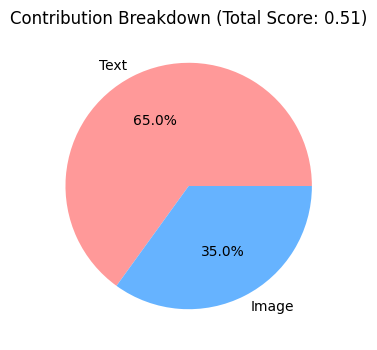

In [76]:
# Text Input & Path to Image/Video/Audio
# text_input = "The patient demonstrates severe and persistent impairments in social communication, total lack of eye contact, failure to respond to name, and highly restricted, repetitive patterns of behavior."
# image_path = "./bad.jpg"
text_input ="The child displays healthy social engagement, maintains good eye contact, is very active in communication, and plays well with peers."
image_path = "./good.png"

# video_path = "path/to/child_video.mp4"
# audio_path = "path/to/child_audio.wav"

print("Processing all modalities...")

scores = [
    asd.analyze_text(text_input),
    asd.analyze_image(image_path),
    # asd.analyze_video(video_path),
    # asd.analyze_audio(audio_path)
]

# Final decision based on all modality scores
risk, avg_score, used_weights = asd.final_decision(scores)

print(f"\n----- FINAL SYSTEM PREDICTION -----")
print(f"ASD Risk Level: {risk} | Confidence: {avg_score:.2f}")

# Clinical interpretation of the score
print("\n--- Clinical Interpretation ---")
print(asd.get_natural_language_explanation(avg_score))

# Bonus: Explanation of contribution from each modality
asd.explain_contribution(scores, used_weights)

# Visualize the contribution of each modality to the final prediction
plt.figure(figsize=(6, 4))
contributions = [scores[i] * used_weights[i] for i in range(len(scores))]
plt.pie(contributions, labels=["Text", "Image"], autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title(f"Contribution Breakdown (Total Score: {avg_score:.2f})")
plt.show()